<a href="https://colab.research.google.com/github/Jayaram13690/VoltStream-ML-Project/blob/main/VoltStream_Energy_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VoltStream Smart Energy Prediction System

## Problem Statements

### 1. Regression Problem
Predict the next month energy bill using Linear Regression.

### 2. Classification Problem
Predict whether a day is a High Usage Day or Low Usage Day using Logistic Regression.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay

from sklearn.linear_model import LinearRegression, LogisticRegression


from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(42)

timestamps = pd.date_range(start="2024-01-01", end="2025-12-31 23:00:00", freq="h")

rows = len(timestamps)

df = pd.DataFrame({"timestamp": timestamps})

In [3]:
df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = (df["timestamp"].dt.dayofweek)

df["month"] = (df["timestamp"].dt.month)

In [4]:
weather_conditions = ["sunny","cloudy","rainy"]

df["weather"] = np.random.choice(weather_conditions,size=rows,p=[0.5, 0.3, 0.2])

In [5]:
def generate_temperature(month):
    if month in [3,4,5]:
        return np.random.normal(30, 3)

    elif month in [6,7,8]:
        return np.random.normal(35, 4)

    elif month in [9,10]:
        return np.random.normal(28, 3)

    else:
        return np.random.normal(22, 4)

df["temperature"] = (df["month"].apply(generate_temperature))

In [6]:
solar_generation = []

for _, row in df.iterrows():
    hour = row["hour"]
    weather = row["weather"]

    if 6 <= hour <= 18:
        base = (np.sin((hour - 6) / 12 * np.pi) * 8)

        if weather == "cloudy":
            base *= 0.6

        elif weather == "rainy":
            base *= 0.3

        solar_generation.append(
            max(base, 0)
        )

    else:
        solar_generation.append(0)

df["solar_generation"] = solar_generation

In [7]:
df["hvac_usage"] = ((df["temperature"] - 20) * 0.15 + np.random.normal(1.5, 0.5, rows))

df["hvac_usage"] = (df["hvac_usage"].clip(lower=0))

In [8]:
df["ev_charger_usage"] = np.random.choice([0, 0, 0, 2, 3, 4, 5],size=rows)

In [9]:
df["kitchen_usage"] = np.where(
    df["hour"].isin([7,8,13,14,19,20]),

    np.random.uniform(1.5, 3.5, rows),

    np.random.uniform(0.2, 1.0, rows)
)

In [10]:
df["battery_level"] = np.random.uniform(25, 100, rows)

In [11]:
df["peak_hour"] = np.where(df["hour"].isin([18,19,20,21]), "yes", "no")

In [12]:
df["grid_usage"] = (
    df["hvac_usage"]
    + df["ev_charger_usage"]
    + df["kitchen_usage"]
    - (df["solar_generation"] * 0.5)
    + np.random.normal(2, 1, rows)
)

df["grid_usage"] = (
    df["grid_usage"]
    .clip(lower=0)
)

In [13]:
df["daily_consumption"] = (
    df["grid_usage"]
    + df["hvac_usage"]
    + df["kitchen_usage"]
)

In [14]:
base_rate = 8

peak_multiplier = np.where(
    df["peak_hour"] == "yes",
    1.4,
    1.0
)

solar_discount = (
    df["solar_generation"] * 1.0
)

ev_surcharge = (
    df["ev_charger_usage"] * 2.5
)

# Random household behavior noise
behavior_noise = np.random.normal(
    0,
    18,
    rows
)

# Random seasonal fluctuation
seasonal_variation = np.sin(
    df["month"] * np.pi / 6
) * 12

df["predicted_bill"] = (
    df["daily_consumption"]
    * base_rate
    * peak_multiplier
    + ev_surcharge
    - solar_discount
    + seasonal_variation
    + behavior_noise
)

df["predicted_bill"] = (
    df["predicted_bill"]
    .clip(lower=20)
)

In [15]:
threshold = (df["predicted_bill"].quantile(0.75))

df["high_usage"] = np.where(df["predicted_bill"] > threshold,1,0)

In [16]:
df.loc[np.random.choice(df.index, 500), "hvac_usage"] = np.nan

df.loc[np.random.choice(df.index, 300), "ev_charger_usage"] = np.nan

In [17]:
df = pd.concat([df, df.iloc[:20]])

In [18]:
df.head()

,timestamp,hour,day_of_week,month,weather,temperature,solar_generation,hvac_usage,ev_charger_usage,kitchen_usage,battery_level,peak_hour,grid_usage,daily_consumption,predicted_bill,high_usage
0,2024-01-01 00:00:00,0,0,1,sunny,29.128096,0.0,2.980752,0.0,0.370377,35.478901,no,5.385790,8.736919,70.065149,0
1,2024-01-01 01:00:00,1,0,1,rainy,20.524468,0.0,NaN,5.0,0.332210,46.441750,no,7.547897,9.095449,111.503163,0
2,2024-01-01 02:00:00,2,0,1,cloudy,21.881970,0.0,0.842292,0.0,0.839414,69.082660,no,2.738783,4.420489,20.000000,0
3,2024-01-01 03:00:00,3,0,1,cloudy,27.853743,0.0,3.081333,NaN,0.773880,28.054087,no,7.298577,11.153790,126.672398,1
4,2024-01-01 04:00:00,4,0,1,sunny,22.588043,0.0,1.238732,2.0,0.650559,50.024253,no,5.836672,7.725964,68.721783,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17564 entries, 0 to 19
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          17564 non-null  datetime64[ns]
 1   hour               17564 non-null  int32         
 2   day_of_week        17564 non-null  int32         
 3   month              17564 non-null  int32         
 4   weather            17564 non-null  object        
 5   temperature        17564 non-null  float64       
 6   solar_generation   17564 non-null  float64       
 7   hvac_usage         17075 non-null  float64       
 8   ev_charger_usage   17264 non-null  float64       
 9   kitchen_usage      17564 non-null  float64       
 10  battery_level      17564 non-null  float64       
 11  peak_hour          17564 non-null  object        
 12  grid_usage         17564 non-null  float64       
 13  daily_consumption  17564 non-null  float64       
 14  predicted_bill

In [20]:
df.describe()

,timestamp,hour,day_of_week,month,temperature,solar_generation,hvac_usage,ev_charger_usage,kitchen_usage,battery_level,grid_usage,daily_consumption,predicted_bill,high_usage
count,17564,17564.000000,17564.000000,17564.000000,17564.000000,1.756400e+04,17075.000000,17264.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000
mean,2024-12-31 01:31:21.985880320,11.497723,2.988385,6.513550,28.289725,1.883752e+00,2.742535,1.997741,1.078252,62.408122,6.882335,10.702592,95.970974,0.249943
min,2024-01-01 00:00:00,0.000000,0.000000,1.000000,7.379654,0.000000e+00,0.000000,0.000000,0.200183,25.018234,0.000000,0.258672,20.000000,0.000000
25%,2024-07-01 02:45:00,5.000000,1.000000,4.000000,24.027117,0.000000e+00,2.020188,0.000000,0.468178,43.497054,4.920077,8.177920,64.846739,0.000000
50%,2024-12-31 01:30:00,11.000000,3.000000,7.000000,28.514648,2.939152e-16,2.749523,2.000000,0.730918,62.309730,6.841687,10.592082,92.286623,0.000000
75%,2025-07-02 00:15:00,17.000000,5.000000,10.000000,32.436324,4.000000e+00,3.462069,4.000000,1.125365,81.216510,8.862434,13.151971,121.885329,0.000000
max,2025-12-31 23:00:00,23.000000,6.000000,12.000000,50.769324,8.000000e+00,6.356749,5.000000,3.499706,99.985434,17.560224,26.570238,294.083678,1.000000
std,NaN,6.921506,2.002129,3.452707,6.172766,2.563971e+00,1.044496,1.929939,0.897559,21.710685,2.797268,3.636209,43.954329,0.432992


In [21]:
df.isnull().sum()

,0
timestamp,0
hour,0
day_of_week,0
month,0
weather,0
temperature,0
solar_generation,0
hvac_usage,489
ev_charger_usage,300
kitchen_usage,0


In [22]:
df["hvac_usage"] = (df["hvac_usage"].fillna(df["hvac_usage"].mean()))

df["ev_charger_usage"] = (df["ev_charger_usage"].fillna(df["ev_charger_usage"].mean()))

In [23]:
df.isnull().sum()

,0
timestamp,0
hour,0
day_of_week,0
month,0
weather,0
temperature,0
solar_generation,0
hvac_usage,0
ev_charger_usage,0
kitchen_usage,0


In [24]:
df.duplicated().sum()

np.int64(20)

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
weather_encoder = LabelEncoder()
df["weather"] = weather_encoder.fit_transform(df["weather"])

peak_hour_encoder = LabelEncoder()
df["peak_hour"] = peak_hour_encoder.fit_transform(df["peak_hour"])

In [27]:
X = df[[
    "hour",
    "day_of_week",
    "month",
    "weather",
    "temperature",
    "solar_generation",
    "battery_level",
    "hvac_usage",
    "ev_charger_usage",
    "kitchen_usage",
    "peak_hour",
    "grid_usage",
    "daily_consumption"
]]


In [28]:
y = df["predicted_bill"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()

In [31]:
scale_features = [
    "hour",
    "day_of_week",
    "month",
    "temperature",
    "solar_generation",
    "battery_level",
    "hvac_usage",
    "ev_charger_usage",
    "kitchen_usage",
    "grid_usage",
    "daily_consumption"
]

In [32]:
X_train[scale_features] = scaler.fit_transform(X_train[scale_features])

In [33]:
X_train

,hour,day_of_week,month,weather,temperature,solar_generation,battery_level,hvac_usage,ev_charger_usage,kitchen_usage,peak_hour,grid_usage,daily_consumption
7858,-0.219263,0.997911,1.293480,2,-0.885754,1.973038,-0.940338,-0.309599,1.048383,-0.365905,0,-0.396831,-0.483569
11347,1.080845,-0.000605,-0.735903,2,0.018509,-0.732746,-0.625723,0.316158,-1.043721,1.998640,1,0.290047,0.808340
11433,-0.363719,-1.498379,-0.735903,2,0.812406,1.476518,-1.518954,0.215379,1.048383,-0.144726,0,0.255903,0.222398
4216,0.647475,-1.498379,-0.156079,2,1.172679,0.829439,1.520245,0.527219,-1.043721,-0.615954,0,-0.639745,-0.494487
1516,-1.086001,-1.498379,-1.025815,0,-0.507951,-0.732746,-1.024586,0.625628,-1.043721,-0.861280,0,0.474565,0.329618
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-1.086001,-0.999121,-0.735903,1,-0.056152,-0.732746,-1.099567,-0.206951,-1.043721,-0.180208,0,-0.321718,-0.350623
11964,0.069650,-0.999121,-0.445991,0,0.190891,1.141877,1.303473,1.040873,-1.043721,-0.466923,0,-1.105561,-0.669791
5390,0.358563,-1.498379,0.423744,2,1.181630,1.973038,0.765659,1.450412,-1.043721,2.401873,0,-0.051997,0.967586
860,1.225301,-1.498379,-1.315727,0,-2.000769,-0.732746,1.415842,-1.761256,-1.043721,0.605959,1,-0.997783,-1.117505


In [34]:
X_test[scale_features] = scaler.transform(X_test[scale_features])

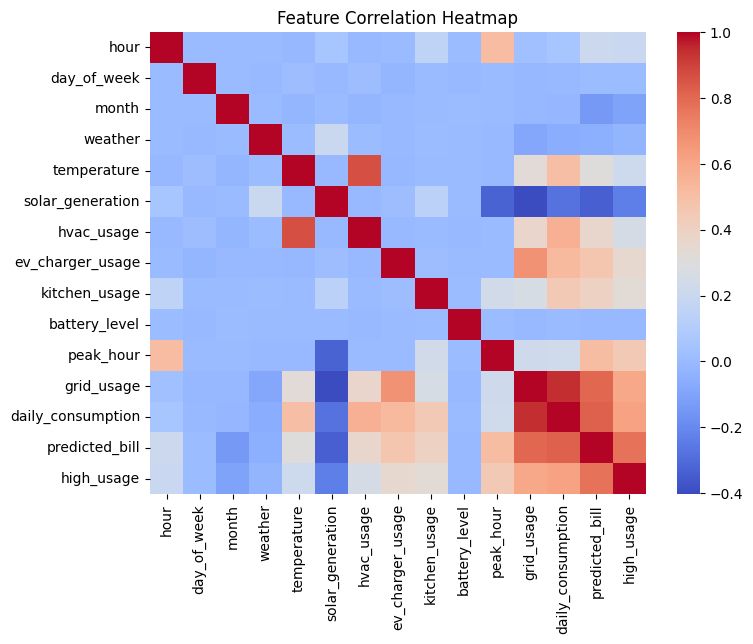

In [35]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(correlation,cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [36]:
correlation = df.corr(numeric_only=True)

correlation["predicted_bill"].sort_values(ascending=False)

,predicted_bill
predicted_bill,1.000000
daily_consumption,0.823829
grid_usage,0.807400
high_usage,0.770558
peak_hour,0.510688
ev_charger_usage,0.463730
kitchen_usage,0.395980
hvac_usage,0.359854
temperature,0.308472
hour,0.209239


In [37]:
linear_model = LinearRegression()

linear_model.fit(X_train,y_train)

LinearRegression()

In [38]:
linear_predictions = linear_model.predict(X_test)

In [39]:
linear_mae = mean_absolute_error(y_test,linear_predictions)

linear_mse = mean_squared_error(y_test,linear_predictions)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test,linear_predictions)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MAE: 15.075320158581315
RMSE: 18.88988410683415
R2 Score: 0.8160878820520164


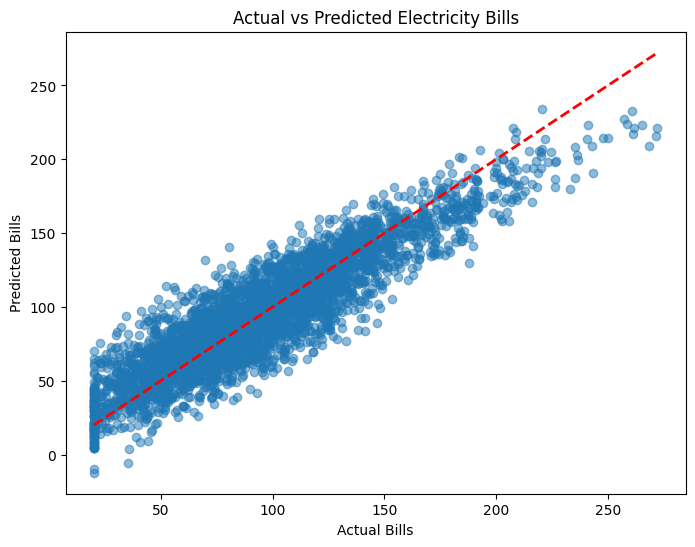

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5
)

# Add the y=x line for ideal predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel("Actual Bills")
plt.ylabel("Predicted Bills")

plt.title("Actual vs Predicted Electricity Bills")

plt.show()

In [41]:
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(linear_model, X, y, cv=tscv, scoring="r2")

print("Cross Validation R2 Scores:")
print(cv_scores)

print("Average CV R2 Score:",cv_scores.mean())

Cross Validation R2 Scores:
[0.64104236 0.68992399 0.80398512 0.81609187 0.78036587]
Average CV R2 Score: 0.746281842162319


### Additional Regression Models

In [42]:
forest_model = RandomForestRegressor(n_estimators=100,random_state=42)

forest_model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [43]:
forest_predictions = forest_model.predict(X_test)

In [44]:
forest_mae = mean_absolute_error(y_test,forest_predictions)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(y_test,forest_predictions)

print("Random Forest Results")
print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R2 Score:", forest_r2)

Random Forest Results
MAE: 14.63568481552331
RMSE: 18.332614357233307
R2 Score: 0.8267789908301684


In [45]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score": [
        linear_r2,
        forest_r2
    ],
    "RMSE": [
        linear_rmse,
        forest_rmse
    ]
})

model_results

,Model,R2 Score,RMSE
0,Linear Regression,0.816088,18.889884
1,Random Forest,0.826779,18.332614


In [46]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

#### Lasso Regression

In [48]:
lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)
lasso_predictions = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions))
lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression Results:")
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)
print("R2 Score:", lasso_r2)

Lasso Regression Results:
MAE: 15.074135150606208
RMSE: 18.881566204821883
R2 Score: 0.8162498127618304


#### Ridge Regression

In [49]:
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results:")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Results:
MAE: 15.07464519633803
RMSE: 18.888787751793476
R2 Score: 0.8161092296817951


#### Support Vector Regressor (SVR)

In [50]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)
svr_predictions = svr_model.predict(X_test)

svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
svr_r2 = r2_score(y_test, svr_predictions)

print("SVR Regression Results:")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2 Score:", svr_r2)

SVR Regression Results:
MAE: 15.165787670867088
RMSE: 19.107826629000492
R2 Score: 0.8118196191311577


#### XGBoost Regressor

In [51]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Regression Results:")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

XGBoost Regression Results:
MAE: 14.856525880178046
RMSE: 18.59906678899422
R2 Score: 0.8217070926727055


#### Decision Tree Regressor

In [52]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression Results:")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Regression Results:
MAE: 20.489283521928325
RMSE: 25.78878263778141
R2 Score: 0.6572216039211876


In [53]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Lasso Regression",
        "Ridge Regression",
        "SVR",
        "XGBoost Regressor",
        "Decision Tree Regressor"
    ],
    "R2 Score": [
        linear_r2,
        forest_r2,
        lasso_r2,
        ridge_r2,
        svr_r2,
        xgb_r2,
        dt_r2
    ],
    "RMSE": [
        linear_rmse,
        forest_rmse,
        lasso_rmse,
        ridge_rmse,
        svr_rmse,
        xgb_rmse,
        dt_rmse
    ]
})

model_results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,RMSE
1,Random Forest,0.826779,18.332614
5,XGBoost Regressor,0.821707,18.599067
2,Lasso Regression,0.816250,18.881566
3,Ridge Regression,0.816109,18.888788
0,Linear Regression,0.816088,18.889884
4,SVR,0.811820,19.107827
6,Decision Tree Regressor,0.657222,25.788783


### Feature Importance / Coefficients for All Models

#### Linear Regression Feature Coefficients

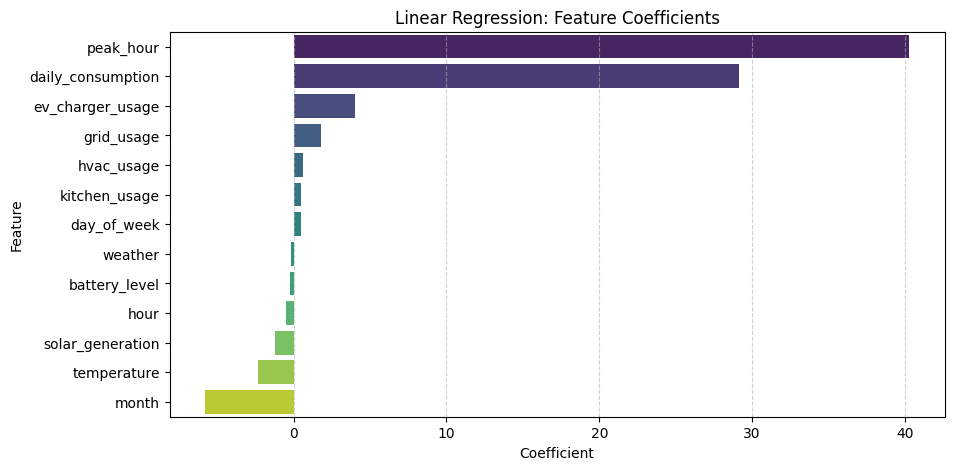

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

linear_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=linear_importance, x='Coefficient', y='Feature', palette='viridis')
plt.title('Linear Regression: Feature Coefficients')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

#### Lasso Regression Feature Coefficients

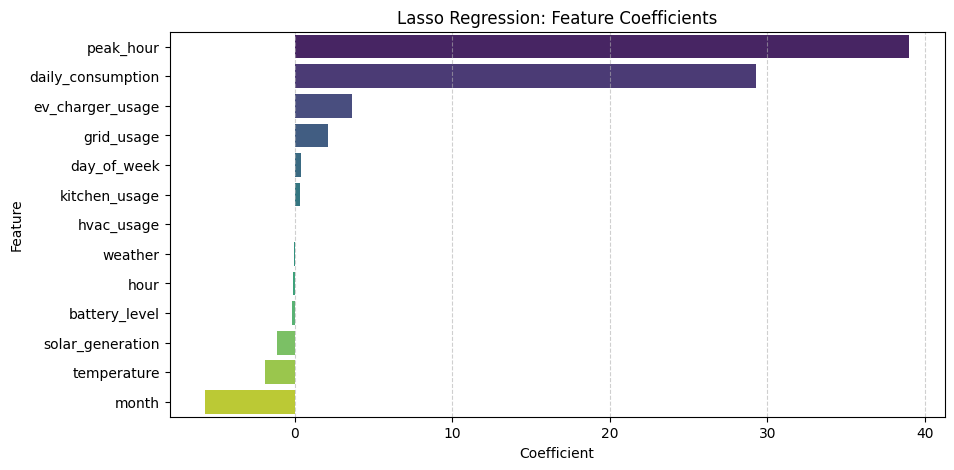

In [55]:
lasso_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=lasso_importance, x='Coefficient', y='Feature', palette='viridis')
plt.title('Lasso Regression: Feature Coefficients')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

#### Ridge Regression Feature Coefficients

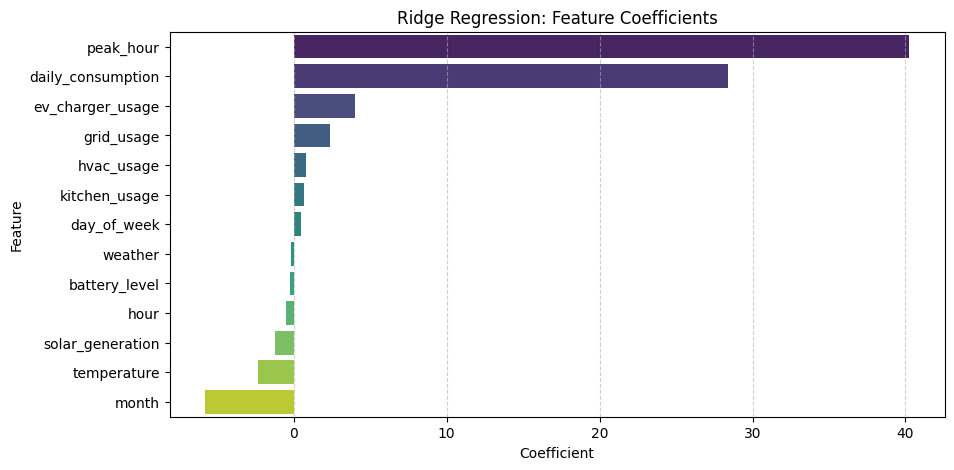

In [56]:
ridge_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=ridge_importance, x='Coefficient', y='Feature', palette='viridis')
plt.title('Ridge Regression: Feature Coefficients')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### RandomForest Feature Importance

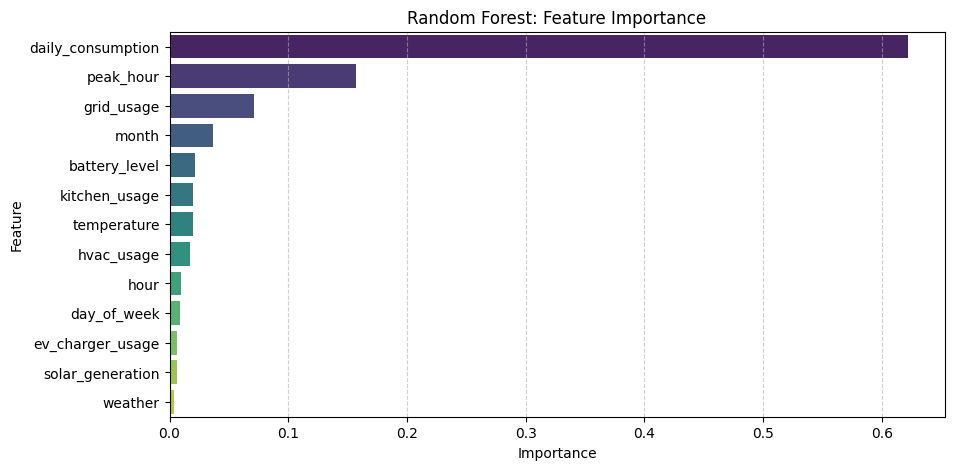

In [57]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest: Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

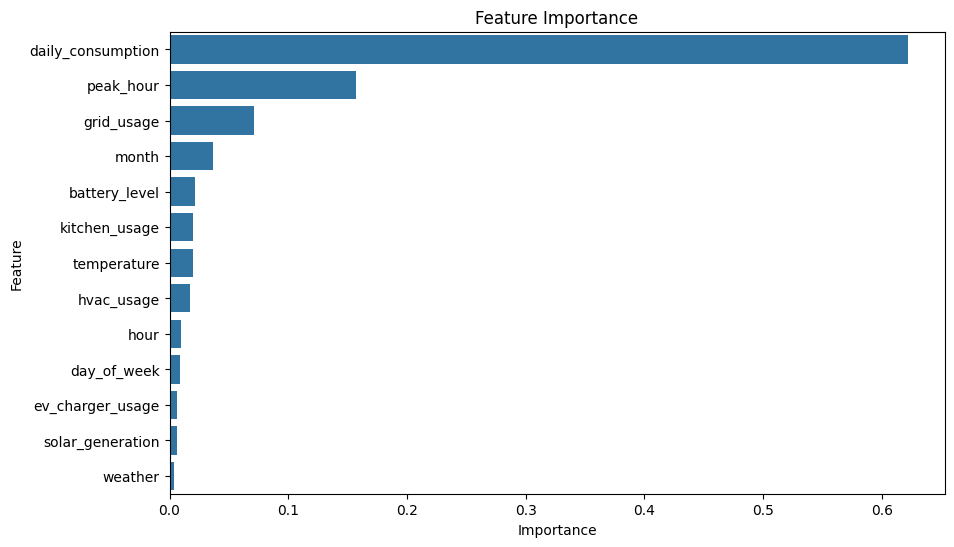

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

#### XGBoost Regressor Feature Importance

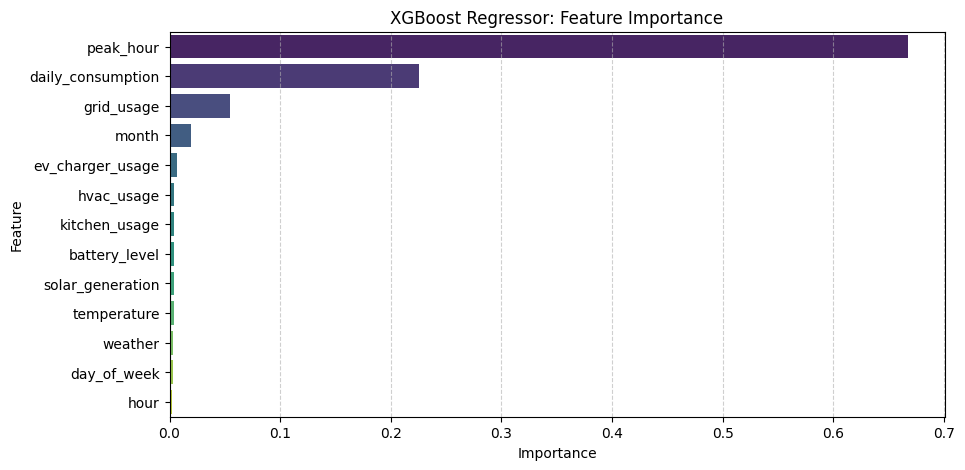

In [59]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=xgb_importance, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Regressor: Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

#### Decision Tree Regressor Feature Importance

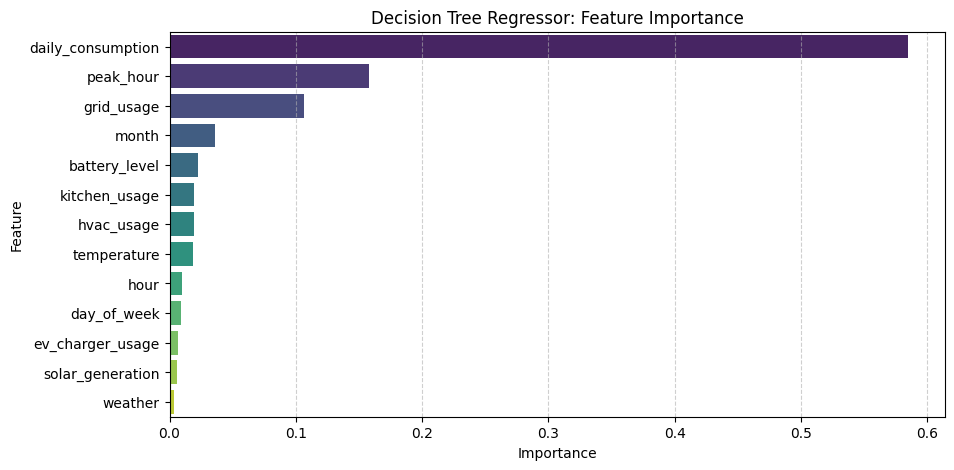

In [60]:
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=dt_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Decision Tree Regressor: Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Problem - 2: Predict High/Low Usage Day

In [61]:
X_cls = df[
    [
        "hour",
        "day_of_week",
        "month",
        "weather",
        "temperature",
        "solar_generation",
        "battery_level",
        "hvac_usage",
        "ev_charger_usage",
        "kitchen_usage",
        "peak_hour"
    ]
]

y_cls = df["high_usage"]

In [62]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

scaler_cls = StandardScaler()

scale_columns = [
    "hour",
    "day_of_week",
    "month",
    "temperature",
    "solar_generation",
    "battery_level",
    "hvac_usage",
    "ev_charger_usage",
    "kitchen_usage"
]



In [63]:
X_train_cls[scale_columns] = scaler_cls.fit_transform(
    X_train_cls[scale_columns]
)

X_test_cls[scale_columns] = scaler_cls.transform(
    X_test_cls[scale_columns]
)

In [64]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_cls,
    y_train_cls
)

LogisticRegression(max_iter=1000, random_state=42)

In [65]:
y_pred = logistic_model.predict(
    X_test_cls
)

y_prob = logistic_model.predict_proba(
    X_test_cls
)[:,1]

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

accuracy = accuracy_score(y_test_cls,y_pred)

precision = precision_score(y_test_cls,y_pred)

recall = recall_score(y_test_cls,y_pred)

f1 = f1_score(y_test_cls,y_pred)

auc = roc_auc_score(y_test_cls,y_prob)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(auc,4))

Accuracy : 0.8869
Precision: 0.8085
Recall   : 0.7172
F1 Score : 0.7601
ROC-AUC  : 0.9452


In [67]:
print(classification_report(y_test_cls,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      2632
           1       0.81      0.72      0.76       877

    accuracy                           0.89      3509
   macro avg       0.86      0.83      0.84      3509
weighted avg       0.88      0.89      0.88      3509



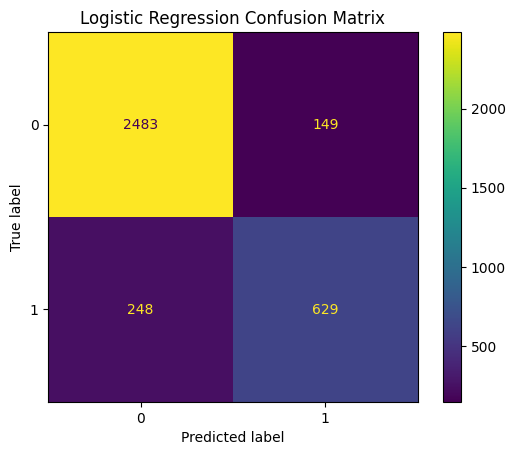

In [68]:
cm = confusion_matrix(
    y_test_cls,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

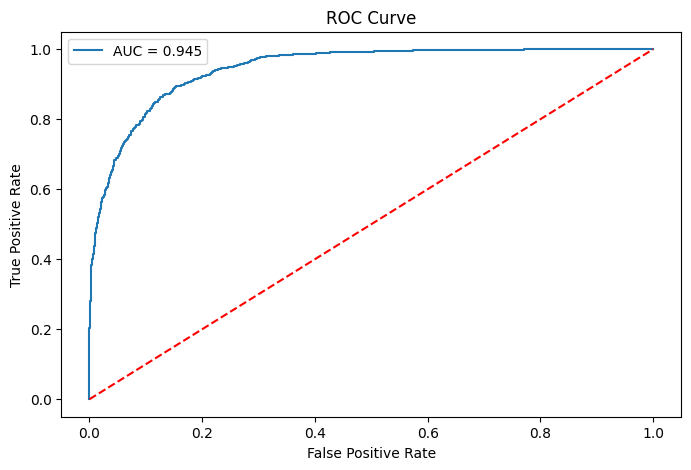

In [69]:
fpr, tpr, thresholds = roc_curve(
    y_test_cls,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    'r--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

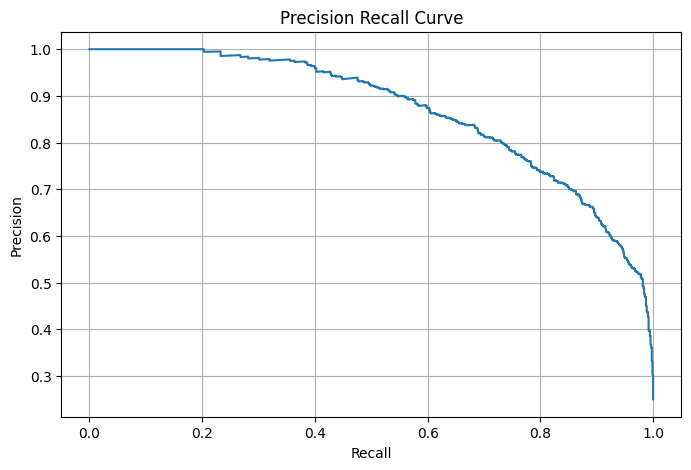

In [73]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test_cls,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid()

plt.show()

In [74]:
f1_scores = (
    2 * precision_curve * recall_curve
) / (
    precision_curve + recall_curve + 1e-10
)

best_index = np.argmax(
    f1_scores[:-1]
)

best_threshold = thresholds[
    best_index
]

print(
    "Best Threshold:",
    round(best_threshold,3)
)

Best Threshold: 0.328


In [75]:
y_pred_best = (
    y_prob >= best_threshold
).astype(int)

print(
    classification_report(
        y_test_cls,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2632
           1       0.73      0.82      0.77       877

    accuracy                           0.88      3509
   macro avg       0.83      0.86      0.85      3509
weighted avg       0.89      0.88      0.88      3509



### Additional Classification Models

In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

#### K-Nearest Neighbors (KNN) Classifier

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      2632
           1       0.77      0.67      0.71       877

    accuracy                           0.87      3509
   macro avg       0.83      0.80      0.81      3509
weighted avg       0.86      0.87      0.86      3509



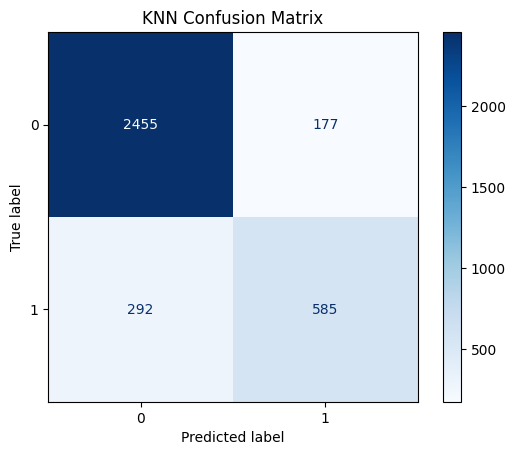

In [77]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_cls, y_train_cls)
knn_predictions = knn_model.predict(X_test_cls)

print("KNN Classification Report:")
print(classification_report(y_test_cls, knn_predictions))
ConfusionMatrixDisplay.from_predictions(y_test_cls, knn_predictions, cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

#### Support Vector Classifier (SVC)

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      2632
           1       0.83      0.67      0.74       877

    accuracy                           0.88      3509
   macro avg       0.86      0.81      0.83      3509
weighted avg       0.88      0.88      0.88      3509



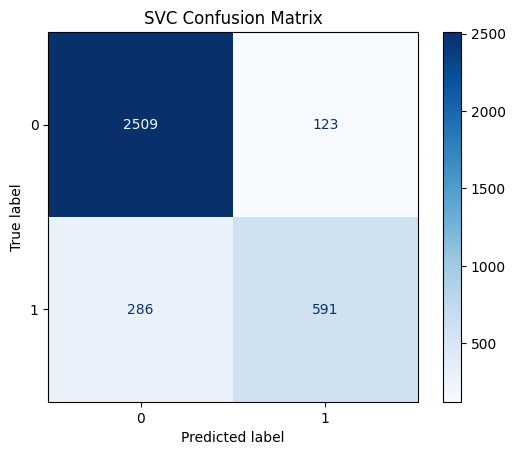

In [78]:
svc_model = SVC(random_state=42, probability=True)
svc_model.fit(X_train_cls, y_train_cls)
svc_predictions = svc_model.predict(X_test_cls)

print("SVC Classification Report:")
print(classification_report(y_test_cls, svc_predictions))
ConfusionMatrixDisplay.from_predictions(y_test_cls, svc_predictions, cmap='Blues')
plt.title("SVC Confusion Matrix")
plt.show()

#### Random Forest Classifier

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      2632
           1       0.81      0.68      0.74       877

    accuracy                           0.88      3509
   macro avg       0.85      0.81      0.83      3509
weighted avg       0.88      0.88      0.88      3509



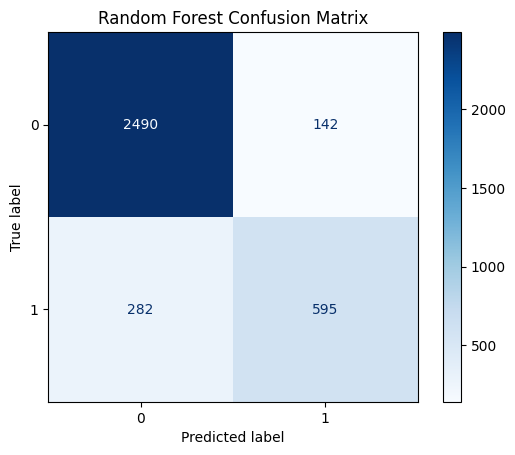

In [79]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_cls, y_train_cls)
rf_predictions = rf_model.predict(X_test_cls)

print("Random Forest Classification Report:")
print(classification_report(y_test_cls, rf_predictions))
ConfusionMatrixDisplay.from_predictions(y_test_cls, rf_predictions, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

#### XGBoost Classifier

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2632
           1       0.79      0.69      0.73       877

    accuracy                           0.88      3509
   macro avg       0.84      0.81      0.83      3509
weighted avg       0.87      0.88      0.87      3509



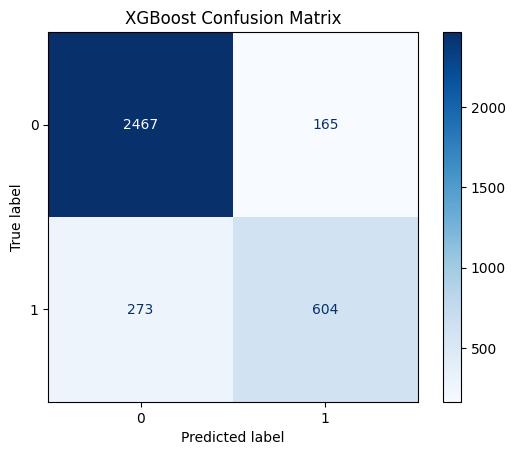

In [80]:
xgb_cls_model = XGBClassifier(random_state=42)
xgb_cls_model.fit(X_train_cls, y_train_cls)
xgb_cls_predictions = xgb_cls_model.predict(X_test_cls)

print("XGBoost Classification Report:")
print(classification_report(y_test_cls, xgb_cls_predictions))
ConfusionMatrixDisplay.from_predictions(y_test_cls, xgb_cls_predictions, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

#### Decision Tree Classifier

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      2632
           1       0.69      0.68      0.68       877

    accuracy                           0.84      3509
   macro avg       0.79      0.79      0.79      3509
weighted avg       0.84      0.84      0.84      3509



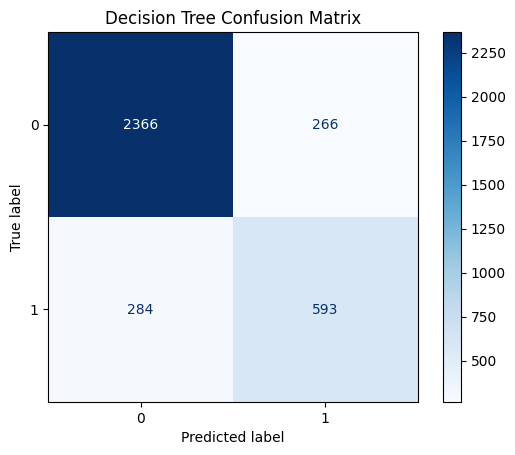

In [81]:
dt_cls_model = DecisionTreeClassifier(random_state=42)
dt_cls_model.fit(X_train_cls, y_train_cls)
dt_cls_predictions = dt_cls_model.predict(X_test_cls)

print("Decision Tree Classification Report:")
print(classification_report(y_test_cls, dt_cls_predictions))
ConfusionMatrixDisplay.from_predictions(y_test_cls, dt_cls_predictions, cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Classification Model Performance Metrics

In [82]:
classification_metrics = []

models = {
    "Logistic Regression": logistic_model,
    "KNN Classifier": knn_model,
    "SVC Classifier": svc_model,
    "Random Forest Classifier": rf_model,
    "XGBoost Classifier": xgb_cls_model,
    "Decision Tree Classifier": dt_cls_model
}

for name, model in models.items():
    # For models that can output probabilities, calculate ROC-AUC and apply threshold
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_cls)[:, 1]
        auc_score = roc_auc_score(y_test_cls, y_prob)
        y_pred = (y_prob >= best_threshold).astype(int)
    else:
        # For models without predict_proba, use direct predictions
        y_pred = model.predict(X_test_cls)
        auc_score = None # Or handle as appropriate if probabilities are needed for specific metrics

    # Classification report for class 1 (high usage)
    report = classification_report(y_test_cls, y_pred, output_dict=True)
    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_score_1 = report['1']['f1-score']

    classification_metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_cls, y_pred),
        "Precision (Class 1)": precision_1,
        "Recall (Class 1)": recall_1,
        "F1-Score (Class 1)": f1_score_1,
        "ROC-AUC": auc_score
    })

classification_results_df = pd.DataFrame(classification_metrics)
display(classification_results_df.sort_values(by="F1-Score (Class 1)", ascending=False))

,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),ROC-AUC
0,Logistic Regression,0.878883,0.727823,0.823261,0.772606,0.945241
2,SVC Classifier,0.884298,0.761958,0.781072,0.771396,0.938311
3,Random Forest Classifier,0.872043,0.709804,0.825542,0.763310,0.940163
4,XGBoost Classifier,0.873183,0.726891,0.789054,0.756698,0.937077
1,KNN Classifier,0.847250,0.658017,0.809578,0.725971,0.898457
5,Decision Tree Classifier,0.843260,0.690338,0.676169,0.683180,0.787552


### Future Predictions for Regression Problem (Linear Regression)

In [83]:
future_data_point = {
    'hour': 10,
    'day_of_week': 2,
    'month': 7,
    'weather': 0,
    'temperature': 35,
    'solar_generation': 5,
    'battery_level': 80,
    'hvac_usage': 3,
    'ev_charger_usage': 1,
    'kitchen_usage': 2,
    'peak_hour': 0,
    'grid_usage': 10,
    'daily_consumption': 15
}

future_data = pd.DataFrame([future_data_point])

# Scale numerical features for the future data point
future_data[scale_features] = scaler.transform(future_data[scale_features])

# Predict the future bill using the linear regression model
future_bill_prediction = linear_model.predict(future_data[X_train.columns])

print(f"Predicted future electricity bill: ${future_bill_prediction[0]:.2f}")

Predicted future electricity bill: $119.35


### Future Predictions for Classification Problem (Logistic Regression)

In [84]:
future_usage_data_point = {
    'hour': 20,
    'day_of_week': 5,
    'month': 12,
    'weather': 0,
    'temperature': 25,
    'solar_generation': 0,
    'battery_level': 40,
    'hvac_usage': 4.0,
    'ev_charger_usage': 5,
    'kitchen_usage': 3,
    'peak_hour': 0
}

future_usage_data = pd.DataFrame([future_usage_data_point])

# Scale numerical features
future_usage_data[scale_columns] = scaler_cls.transform(future_usage_data[scale_columns])

# Predict using the logistic regression model
future_prediction = logistic_model.predict(future_usage_data[X_train_cls.columns])
future_probability = logistic_model.predict_proba(future_usage_data[X_train_cls.columns])[:, 1]

if future_prediction[0] == 1:
    print(f"Predicted: High Usage Day (Probability: {future_probability[0]*100:.2f}%)")
else:
    print(f"Predicted: Low Usage Day (High Usage Probability: {future_probability[0]*100:.2f}%)")

Predicted: High Usage Day (Probability: 98.48%)


### Additional Future Predictions

In [85]:
future_data = pd.DataFrame({
    "hour": [18],
    "day_of_week": [2],
    "month": [6],
    "weather": [2],
    "temperature": [34],
    "solar_generation": [6.5],
    "battery_level": [78],
    "hvac_usage": [4.2],
    "ev_charger_usage": [3.0],
    "kitchen_usage": [2.1],
    "peak_hour": [1],
    "grid_usage": [8.4],
    "daily_consumption": [14.5]
})

future_data[scale_features] = scaler.transform(future_data[scale_features])

future_bill_prediction = (linear_model.predict(future_data[X_train.columns]))

print(f"Predicted Future Electricity Bill: ${future_bill_prediction[0]:.2f}")

Predicted Future Electricity Bill: $159.99


In [86]:
future_usage_data = pd.DataFrame({
    "hour": [19],
    "day_of_week": [5],
    "month": [7],
    "weather": [2],   # sunny
    "temperature": [36],
    "solar_generation": [2.5],
    "battery_level": [45],
    "hvac_usage": [6.5],
    "ev_charger_usage": [5.0],
    "kitchen_usage": [3.2],
    "peak_hour": [1]   # yes
})

# Scale numerical features for the future usage data point
future_usage_data[scale_columns] = scaler_cls.transform(future_usage_data[scale_columns])

future_prediction = logistic_model.predict(future_usage_data[X_train_cls.columns])
prediction_probability = logistic_model.predict_proba(future_usage_data[X_train_cls.columns])[:, 1]

print(f"High Usage Probability: {prediction_probability[0]*100:.2f} %")

if future_prediction[0] == 1:
    print("Predicted Usage Day: High Usage Day")

else:
    print("Predicted Usage Day: Low Usage Day")

High Usage Probability: 100.00 %
Predicted Usage Day: High Usage Day


In [87]:
future_usage_data_2 = pd.DataFrame({
    "hour": [10],
    "day_of_week": [2],
    "month": [1],
    "weather": [2],
    "temperature": [42],
    "solar_generation": [2.5],
    "battery_level": [90],
    "hvac_usage": [4.5],
    "ev_charger_usage": [0.0],
    "kitchen_usage": [0.8],
    "peak_hour": [0]
})

# Scale numerical features for the future usage data point
future_usage_data_2[scale_columns] = scaler_cls.transform(future_usage_data_2[scale_columns])

low_prediction = logistic_model.predict(future_usage_data_2[X_train_cls.columns])
low_probability = logistic_model.predict_proba(future_usage_data_2[X_train_cls.columns])[:, 1]

print(f"High Usage Probability: {low_probability[0]*100:.2f} %")

if low_prediction[0] == 1:
    print("Predicted Usage Day: High Usage Day")

else:
    print("Predicted Usage Day: Low Usage Day")

High Usage Probability: 10.54 %
Predicted Usage Day: Low Usage Day
